In [27]:
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, accuracy_score

In [28]:
from dotenv import load_dotenv
load_dotenv()

True

In [29]:
data_dir = os.getenv("DATA_DIR")
datasplits_dir = os.getenv("DATASPLITS_DIR")
embeddings_dir = os.getenv("EMBEDDINGS_DIR")

text_train_path = os.path.join(datasplits_dir, "text_train.tsv")
text_val_path = os.path.join(datasplits_dir, "text_val.tsv")
text_test_path = os.path.join(datasplits_dir, "text_test.tsv")

train_bert_path = os.path.join(embeddings_dir, "train_bert.npy")
val_bert_path = os.path.join(embeddings_dir, "val_bert.npy")
test_bert_path = os.path.join(embeddings_dir, "test_bert.npy")

train_roberta_path = os.path.join(embeddings_dir, "train_roberta.npy")
val_roberta_path = os.path.join(embeddings_dir, "val_roberta.npy")
test_roberta_path = os.path.join(embeddings_dir, "test_roberta.npy")

train_bertweet_path = os.path.join(embeddings_dir, "train_bertweet.npy")
val_bertweet_path = os.path.join(embeddings_dir, "val_bertweet.npy")
test_bertweet_path = os.path.join(embeddings_dir, "test_bertweet.npy")

In [30]:
train_bert = np.load(train_bert_path)
val_bert = np.load(val_bert_path)
test_bert = np.load(test_bert_path)

train_roberta = np.load(train_roberta_path)
val_roberta = np.load(val_roberta_path)
test_roberta = np.load(test_roberta_path)

train_bertweet = np.load(train_bertweet_path)
val_bertweet = np.load(val_bertweet_path)
test_bertweet = np.load(test_bertweet_path)

In [31]:

text_train_df = pd.read_csv(text_train_path, sep='\t')
text_val_df = pd.read_csv(text_val_path, sep='\t')
text_test_df = pd.read_csv(text_test_path, sep='\t')

print(f"text train set size: {len(text_train_df)}")
print(f"text val set size: {len(text_val_df)}")
print(f"text test set size: {len(text_test_df)}")

text_train_df.head()

text train set size: 11240
text val set size: 2409
text test set size: 2409


,tweet_text,text_info,text_human,cleaned_text_bert,cleaned_text_bertweet
0,Good to see supplies from #chinaaid reaching t...,informative,rescue_volunteering_or_donation_effort,Good to see supplies from chinaaid reaching th...,Good to see supplies from #chinaaid reaching t...
1,Harvey to Impact North Texas Construction Indu...,informative,infrastructure_and_utility_damage,Harvey to Impact North Texas Construction Indu...,Harvey to Impact North Texas Construction Indu...
2,Took granddaughters back to school in Mexico C...,not_informative,not_humanitarian,Took granddaughters back to school in Mexico C...,Took granddaughters back to school in Mexico C...
3,"NEWS: At least 200 people, including 21 childr...",informative,affected_individuals,"NEWS: At least 200 people, including 21 childr...","NEWS: At least 200 people, including 21 childr..."
4,Press Release: Citizens to open additional Cat...,informative,rescue_volunteering_or_donation_effort,Press Release: Citizens to open additional Cat...,Press Release: Citizens to open additional Cat...


In [32]:
#Task 1: Binary (text_info)
le_info = LabelEncoder()
le_info.fit(text_train_df["text_info"])  # Adatta solo sul train

train_labels_task1 = le_info.transform(text_train_df["text_info"])
val_labels_task1 = le_info.transform(text_val_df["text_info"])
test_labels_task1 = le_info.transform(text_test_df["text_info"])

#Task 2: Multiclasse (text_human)
le_human = LabelEncoder()
le_human.fit(text_train_df["text_human"])

train_labels_task2 = le_human.transform(text_train_df["text_human"])
val_labels_task2 = le_human.transform(text_val_df["text_human"])
test_labels_task2 = le_human.transform(text_test_df["text_human"])

#Mapping classi e label
print("Task 1 classes:", dict(zip(le_info.classes_, le_info.transform(le_info.classes_))))
print("Task 2 classes:", dict(zip(le_human.classes_, le_human.transform(le_human.classes_))))

Task 1 classes: {'informative': np.int64(0), 'not_informative': np.int64(1)}
Task 2 classes: {'affected_individuals': np.int64(0), 'infrastructure_and_utility_damage': np.int64(1), 'not_humanitarian': np.int64(2), 'other_relevant_information': np.int64(3), 'rescue_volunteering_or_donation_effort': np.int64(4)}


In [33]:
def create_mlp(input_dim, output_dim, is_binary):
    
    input = keras.Input(shape=(input_dim,))

    x = layers.Dense(512, activation='relu')(input)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    output = layers.Dense(output_dim, activation='sigmoid' if is_binary else 'softmax')(x)
    model = keras.Model(inputs=input, outputs=output)

    model.compile(
        loss='binary_crossentropy' if is_binary else 'categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    
    return model

In [34]:
def plot_training_history(history, title="Model Training"):
    """
    Plot accuracy and loss curves for training and validation.

    Parameters:
        history (History): Keras History object returned by model.fit()
        title (str): Title prefix for the plots
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


In [35]:
def train_and_evaluate(name, X_train, y_train, X_val, y_val, X_test, y_test, task=1, label_encoder=None):
    is_binary = (task == 1)
    y_train_enc = y_train if is_binary else to_categorical(y_train)
    y_val_enc = y_val if is_binary else to_categorical(y_val)
    
    model = create_mlp(X_train.shape[1], 1 if is_binary else y_train_enc.shape[1], is_binary)
    print(f"\n🚀 Training MLP on {name.upper()} embeddings (Task {task})")

    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(
        X_train, y_train_enc,
        validation_data=(X_val, y_val_enc),
        epochs=50,
        batch_size=32,
        callbacks=[es],
    )

    plot_training_history(history, title=f"{name.upper()} - Task {task}")
    
    y_pred = model.predict(X_test)
    y_pred_labels = (y_pred > 0.5).astype(int).flatten() if is_binary else np.argmax(y_pred, axis=1)

    # 📊 Report metriche
    acc = accuracy_score(y_test, y_pred_labels)
    avg_type = 'binary' if is_binary else 'macro'
    prec = precision_score(y_test, y_pred_labels, average=avg_type, zero_division=0)
    rec = recall_score(y_test, y_pred_labels, average=avg_type, zero_division=0)
    f1 = f1_score(y_test, y_pred_labels, average=avg_type, zero_division=0)

    print(f"\n📊 Results for {name.upper()} - Task {task}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    # 🧩 Matrice di confusione
    if label_encoder:
        display_labels = label_encoder.classes_
    else:
        display_labels = None

    cm = confusion_matrix(y_test, y_pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap='Blues')
    if not is_binary:
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()

    plt.title(f"Confusion Matrix - {name.upper()} - Task {task}", )
    plt.show()

In [36]:
embedding_sets = {
    "bert": {
        "train": train_bert,
        "val": val_bert,
        "test": test_bert
    },
    "roberta": {
        "train": train_roberta,
        "val": val_roberta,
        "test": test_roberta
    },
    "bertweet": {
        "train": train_bertweet,
        "val": val_bertweet,
        "test": test_bertweet
    }
}


🚀 Training MLP on BERT embeddings (Task 1)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7631 - loss: 0.5112 - val_accuracy: 0.7999 - val_loss: 0.4305
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8145 - loss: 0.4254 - val_accuracy: 0.8207 - val_loss: 0.4083
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8211 - loss: 0.4113 - val_accuracy: 0.8095 - val_loss: 0.4182
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8245 - loss: 0.4040 - val_accuracy: 0.8211 - val_loss: 0.4120
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8164 - loss: 0.4098 - val_accuracy: 0.8169 - val_loss: 0.4071
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8332 - loss: 0.3866 - val_accuracy: 0.7792 - val_loss: 0.4774
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8278 - loss: 0.3879 - val_accuracy: 0.8244 - val_loss: 0.4142
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accura

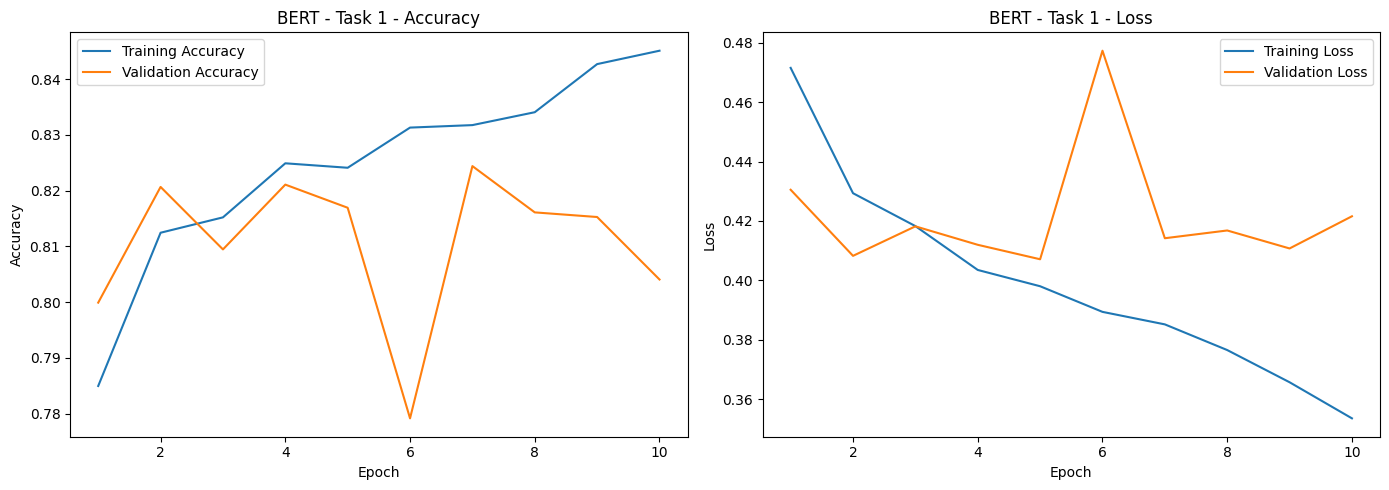

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for BERT - Task 1
Accuracy : 0.8174
Precision: 0.7091
Recall   : 0.6032
F1-score : 0.6519


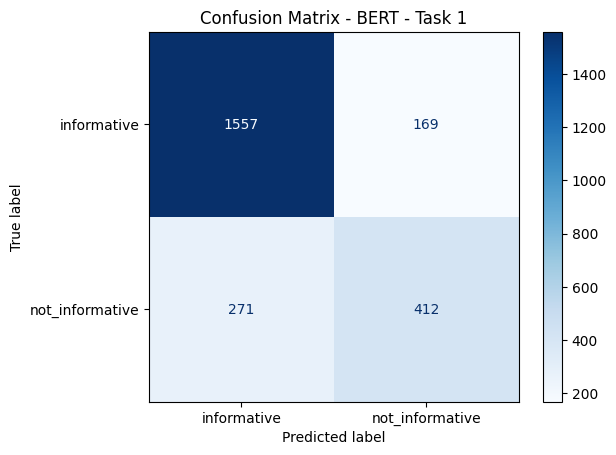


🚀 Training MLP on BERT embeddings (Task 2)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5245 - loss: 1.2045 - val_accuracy: 0.6189 - val_loss: 0.9874
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6181 - loss: 0.9820 - val_accuracy: 0.6202 - val_loss: 0.9372
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6362 - loss: 0.9244 - val_accuracy: 0.6368 - val_loss: 0.9139
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6542 - loss: 0.8885 - val_accuracy: 0.6359 - val_loss: 0.8998
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6591 - loss: 0.8515 - val_accuracy: 0.6463 - val_loss: 0.9164
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6659 - loss: 0.8421 - val_accuracy: 0.6517 - val_loss: 0.9073
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6770 - loss: 0.8136 - val_accuracy: 0.6426 - val_loss: 0.8955
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accura

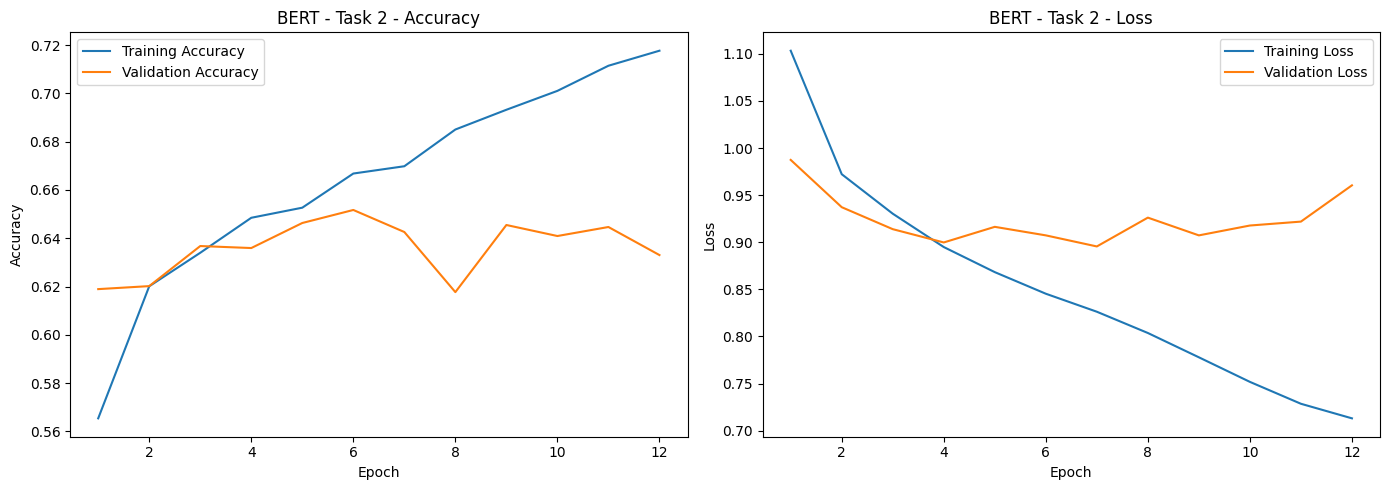

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for BERT - Task 2
Accuracy : 0.6658
Precision: 0.6458
Recall   : 0.6274
F1-score : 0.6331


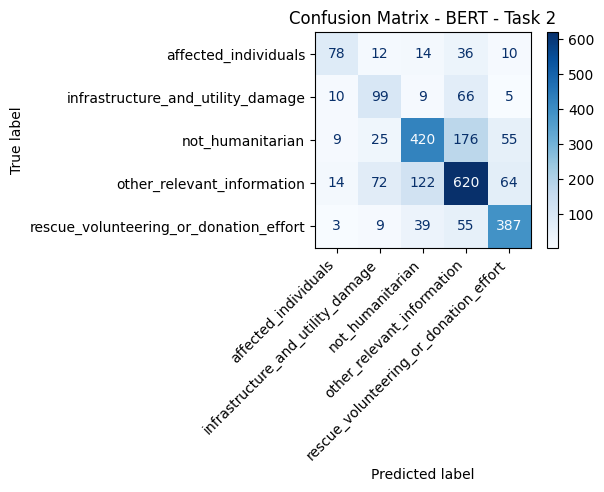

In [37]:
name = "bert"
X_train = embedding_sets[name]["train"]
X_val = embedding_sets[name]["val"]
X_test = embedding_sets[name]["test"]

# 🧪 Task 1: Informative vs Not informative (binario)
train_and_evaluate(name, X_train, train_labels_task1, X_val, val_labels_task1, X_test, test_labels_task1, task=1, label_encoder=le_info)

# 🧪 Task 2: Humanitarian categories (multiclasse)
train_and_evaluate(name, X_train, train_labels_task2, X_val, val_labels_task2, X_test, test_labels_task2, task=2, label_encoder=le_human)


🚀 Training MLP on ROBERTA embeddings (Task 1)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7377 - loss: 0.5483 - val_accuracy: 0.8252 - val_loss: 0.4064
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8216 - loss: 0.4206 - val_accuracy: 0.8227 - val_loss: 0.4150
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8134 - loss: 0.4253 - val_accuracy: 0.8281 - val_loss: 0.4031
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8238 - loss: 0.4059 - val_accuracy: 0.8161 - val_loss: 0.4059
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8339 - loss: 0.3919 - val_accuracy: 0.8248 - val_loss: 0.3929
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8237 - loss: 0.4102 - val_accuracy: 0.8227 - val_loss: 0.3902
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8217 - loss: 0.3958 - val_accuracy: 0.8265 - val_loss: 0.4040
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc

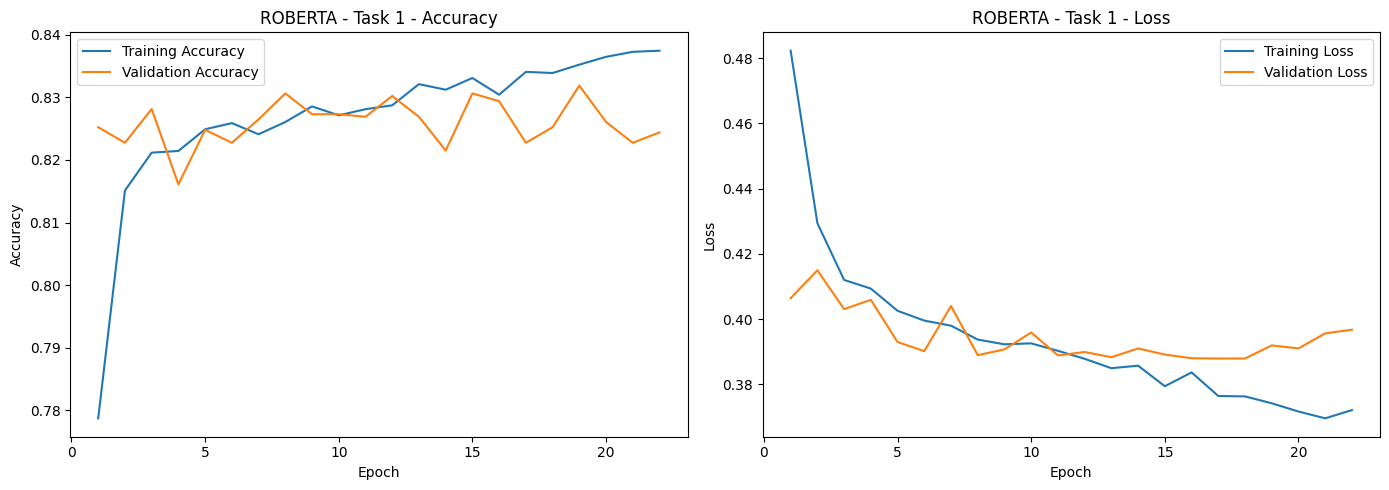

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for ROBERTA - Task 1
Accuracy : 0.8265
Precision: 0.7312
Recall   : 0.6135
F1-score : 0.6672


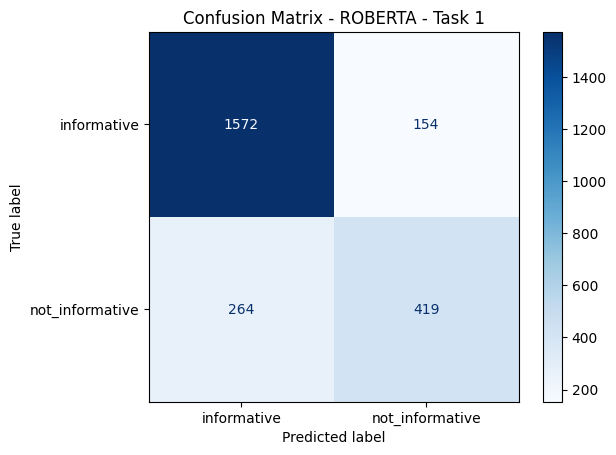


🚀 Training MLP on ROBERTA embeddings (Task 2)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4451 - loss: 1.3171 - val_accuracy: 0.6285 - val_loss: 1.0050
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6209 - loss: 0.9838 - val_accuracy: 0.6430 - val_loss: 0.9022
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6362 - loss: 0.9180 - val_accuracy: 0.6596 - val_loss: 0.8647
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6543 - loss: 0.8870 - val_accuracy: 0.6476 - val_loss: 0.8932
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6571 - loss: 0.8590 - val_accuracy: 0.6700 - val_loss: 0.8320
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6606 - loss: 0.8498 - val_accuracy: 0.6750 - val_loss: 0.8570
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6730 - loss: 0.8323 - val_accuracy: 0.6783 - val_loss: 0.8261
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc

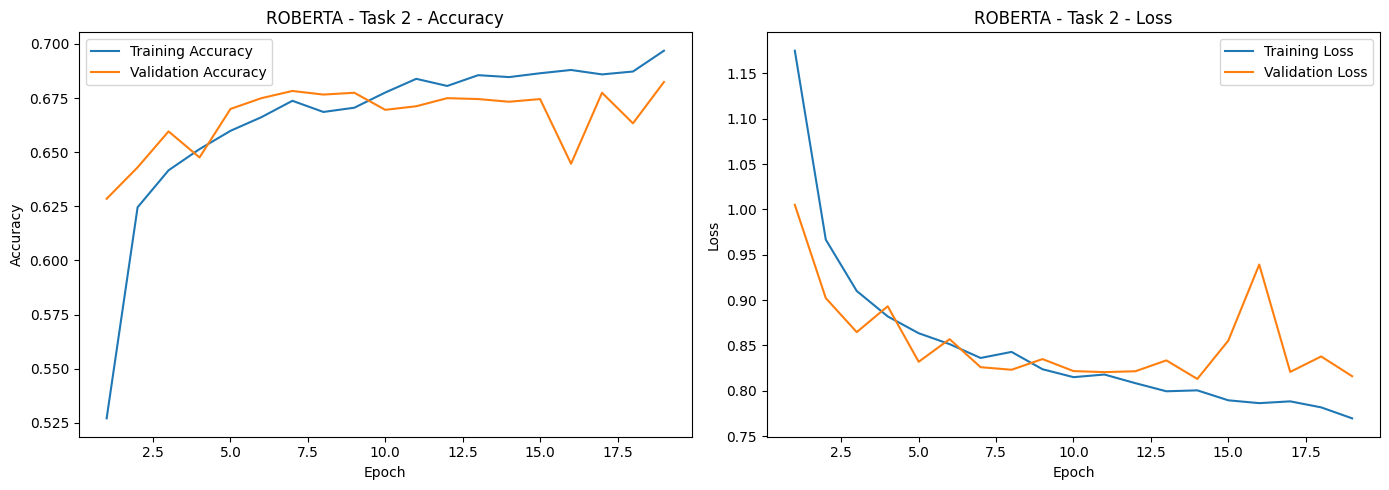

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for ROBERTA - Task 2
Accuracy : 0.6924
Precision: 0.6873
Recall   : 0.6242
F1-score : 0.6459


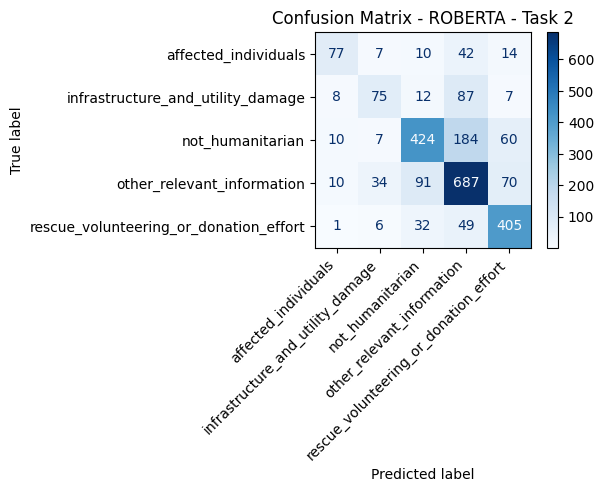

In [38]:
name = "roberta"
X_train = embedding_sets[name]["train"]
X_val = embedding_sets[name]["val"]
X_test = embedding_sets[name]["test"]

# 🧪 Task 1: Informative vs Not informative (binario)
train_and_evaluate(name, X_train, train_labels_task1, X_val, val_labels_task1, X_test, test_labels_task1, task=1,label_encoder=le_info)

# 🧪 Task 2: Humanitarian categories (multiclasse)
train_and_evaluate(name, X_train, train_labels_task2, X_val, val_labels_task2, X_test, test_labels_task2, task=2,label_encoder=le_human)


🚀 Training MLP on BERTWEET embeddings (Task 1)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7449 - loss: 0.5315 - val_accuracy: 0.8165 - val_loss: 0.4355
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7999 - loss: 0.4499 - val_accuracy: 0.7725 - val_loss: 0.4592
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7992 - loss: 0.4507 - val_accuracy: 0.8132 - val_loss: 0.4213
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8072 - loss: 0.4337 - val_accuracy: 0.8140 - val_loss: 0.4275
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8102 - loss: 0.4268 - val_accuracy: 0.8232 - val_loss: 0.4103
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8167 - loss: 0.4247 - val_accuracy: 0.8244 - val_loss: 0.4031
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8140 - loss: 0.4118 - val_accuracy: 0.8290 - val_loss: 0.4046
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - ac

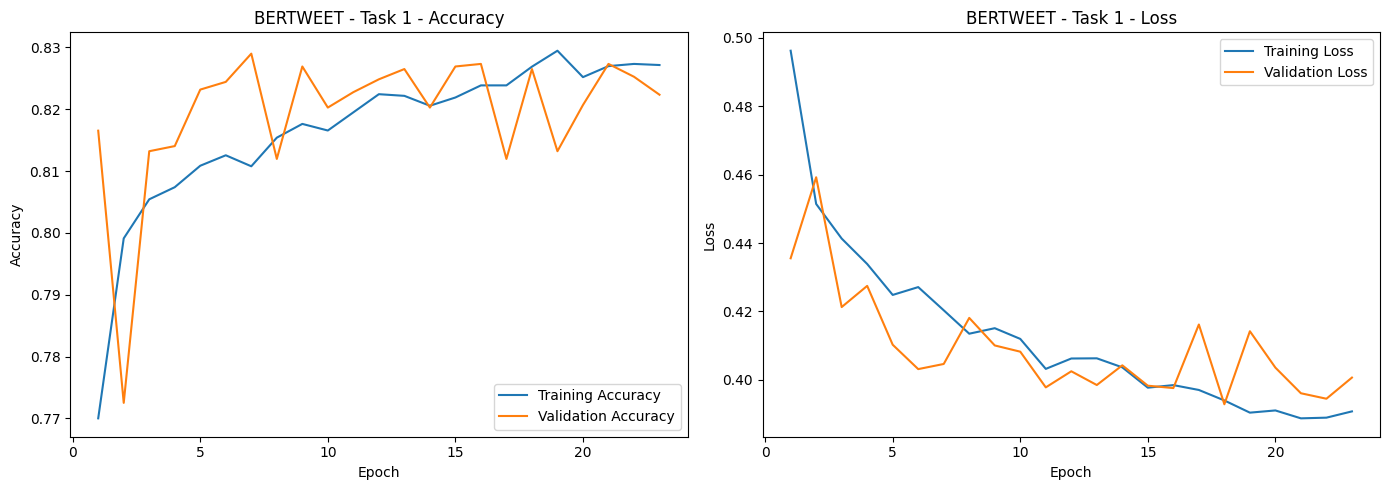

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for BERTWEET - Task 1
Accuracy : 0.8140
Precision: 0.7230
Recall   : 0.5578
F1-score : 0.6298


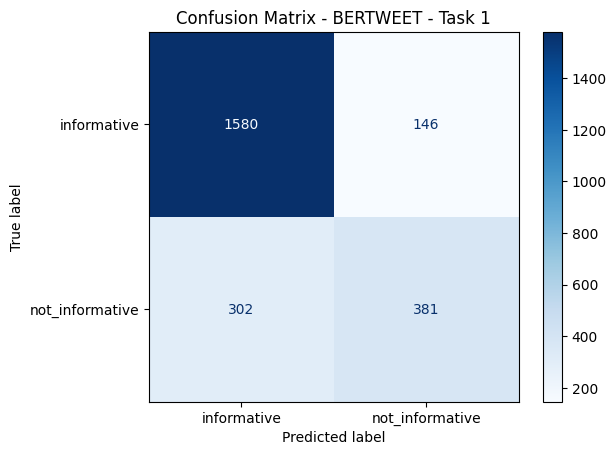


🚀 Training MLP on BERTWEET embeddings (Task 2)
Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4804 - loss: 1.2828 - val_accuracy: 0.6069 - val_loss: 1.0040
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5926 - loss: 1.0461 - val_accuracy: 0.6252 - val_loss: 0.9368
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6159 - loss: 0.9669 - val_accuracy: 0.6467 - val_loss: 0.9185
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6186 - loss: 0.9579 - val_accuracy: 0.6227 - val_loss: 0.9331
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6308 - loss: 0.9424 - val_accuracy: 0.6546 - val_loss: 0.8985
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6418 - loss: 0.9374 - val_accuracy: 0.6584 - val_loss: 0.8837
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6439 - loss: 0.9145 - val_accuracy: 0.6480 - val_loss: 0.8722
Epoch 8/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - ac

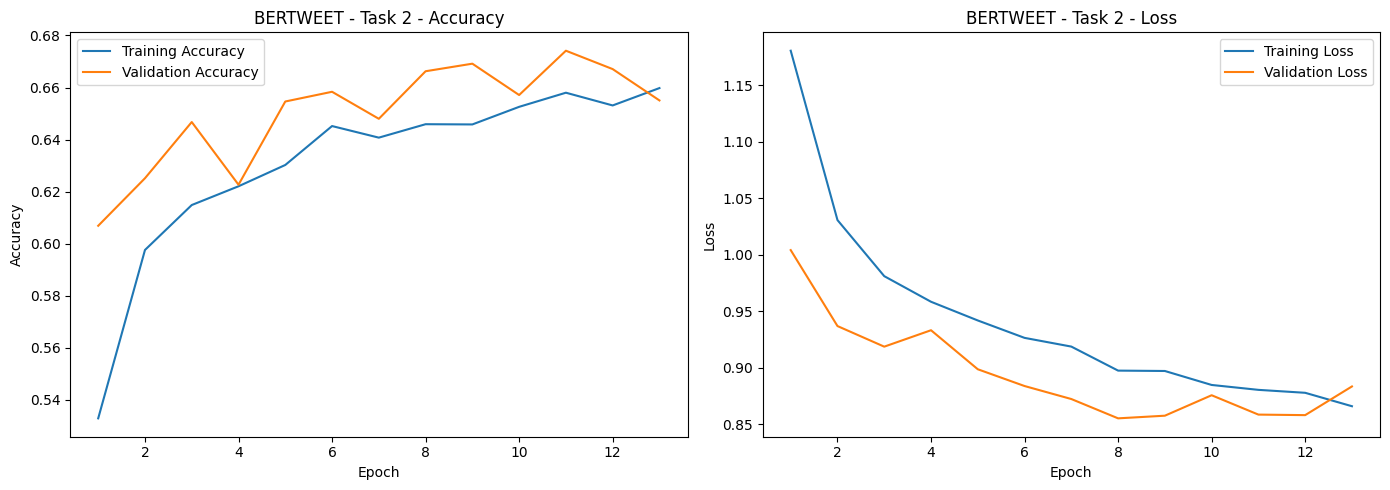

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📊 Results for BERTWEET - Task 2
Accuracy : 0.6654
Precision: 0.6504
Recall   : 0.6005
F1-score : 0.6129


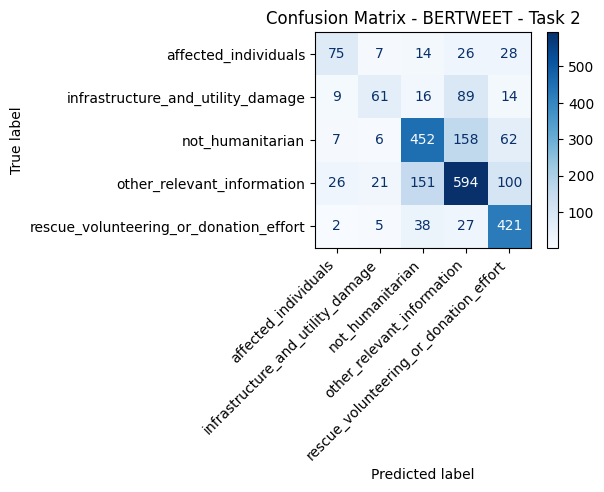

In [39]:
name = "bertweet"
X_train = embedding_sets[name]["train"]
X_val = embedding_sets[name]["val"]
X_test = embedding_sets[name]["test"]

# 🧪 Task 1: Informative vs Not informative (binario)
train_and_evaluate(name, X_train, train_labels_task1, X_val, val_labels_task1, X_test, test_labels_task1, task=1, label_encoder=le_info)

# 🧪 Task 2: Humanitarian categories (multiclasse)
train_and_evaluate(name, X_train, train_labels_task2, X_val, val_labels_task2, X_test, test_labels_task2, task=2, label_encoder=le_human)